<a href="https://colab.research.google.com/github/PacoDLC/trading-algoritmico-a-z-con-python/blob/main/ES_TA_Cap%C3%ADtulo_07_Ingenier%C3%ADa_de_Caracter%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><img alt="Colaboratory logo" height="45px" src="https://www.quantreo.com/wp-content/uploads/2021/10/Original-on-Transparent.png" align="left" hspace="10px" vspace="0px">
<img alt="Colaboratory logo" height="45px" src="https://static-881c.kxcdn.com/wp-content/uploads/2016/03/frogamesLogoFull4.png" align="left" hspace="10px" vspace="0px"></p>

# Ingeniería de Características


En este capítulo, aprenderemos a crear indicadores técnicos por nosotros mismos y a crearlos utilizando la librería de análisis técnico de Python.

### Resumen
* Media móvil simple (SMA)
* Desviación Estándar Móvil (DMS)
* Crear otros indicadores utilizando la librería de Análisis Técnico (ta)

</br>

💰 Únete a la comunidad de [Discord](https://discord.gg/z3dx5XpkX4)

📚 Puedes leer nuestro libro en [Amazon](https://www.amazon.es/Python-para-finanzas-trading-algor%C3%ADtmico-ebook/dp/B0BT4ZS9Q3/)

🖥️ El canal de [YouTube de Quantreo's](https://www.youtube.com/channel/UCp7jckfiEglNf_Gj62VR0pw) (en inglés) y el de [Frogames](https://www.youtube.com/channel/UCMUxXNYrVCv6-bQakhomvBg) en español




In [1]:
!pip install yfinance
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=36e020405a40fac44d0abaca607b5a65c4eb40a8fc96f369abe16feaf522271c
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cycler

colors = cycler('color',
                ['#669FEE', '#66EE91', '#9988DD',
                 '#EECC55', '#88BB44', '#FFBBBB'])
plt.rc('figure', facecolor='#313233')
plt.rc('axes', facecolor="#313233", edgecolor='none',
       axisbelow=True, grid=True, prop_cycle=colors,
       labelcolor='gray')
plt.rc('grid', color='474A4A', linestyle='solid')
plt.rc('xtick', color='gray')
plt.rc('ytick', direction='out', color='gray')
plt.rc('legend', facecolor="#313233", edgecolor="#313233")
plt.rc("text", color="#C9C9C9")
plt.rc('figure', facecolor='#313233')

# Importar los datos

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#plt.style.use('seaborn')
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf

In [17]:
# Importar los datos
df = yf.download("GOOG")
df.columns

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

**Importante**: Los nombres de las columnas son diferentes entre la importación usando la API de Yahoo Finanzas o la importación usando MetaTrader5. Por lo tanto, para eliminar este problema, vamos a renombrar las columnas necesarias siempre con el mismo nombre. En este caso, sólo necesitamos las columnas de Cierre Ajustado

In [18]:
# Renombrar las columnas
df = df[["Close"]]
df.columns = ["close"]
df

,close
Date,
2004-08-19,2.490186
2004-08-20,2.687981
2004-08-23,2.715032
2004-08-24,2.602609
2004-08-25,2.630652
...,...
2025-02-10,188.199997
2025-02-11,187.070007
2025-02-12,185.429993


# Media móvil simple (SMA)

In [19]:
# Media móvil simple
df["SMA 15"] = df[["close"]].rolling(15).mean().shift(1)
df["SMA 60"] = df[["close"]].rolling(60).mean().shift(1)

In [20]:
df

,close,SMA 15,SMA 60
Date,,,
2004-08-19,2.490186,NaN,NaN
2004-08-20,2.687981,NaN,NaN
2004-08-23,2.715032,NaN,NaN
2004-08-24,2.602609,NaN,NaN
2004-08-25,2.630652,NaN,NaN
...,...,...,...
2025-02-10,188.199997,198.602668,188.650950
2025-02-11,187.070007,197.979335,188.758220
2025-02-12,185.429993,197.142001,188.824182


<Axes: xlabel='Date'>

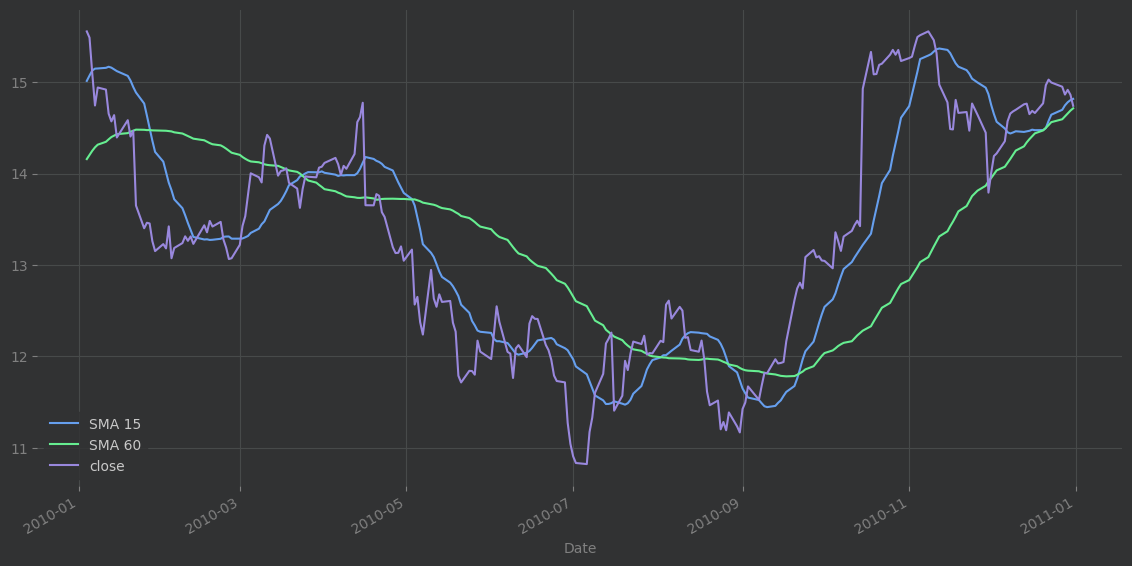

In [21]:
df[["SMA 15", "SMA 60", "close"]].loc["2010"].plot(figsize = (14,7))

# Desviación estándar móvil (MSD)

In [22]:
# Volatilidad del Retorno
df["returns"] = df["close"].pct_change(1) #Incremento porcentual a 1 día

df["MSD 15"] = df[["returns"]].rolling(15).std().shift(1)
df["MSD 60"] = df[["returns"]].rolling(60).std().shift(1)

<Axes: xlabel='Date'>

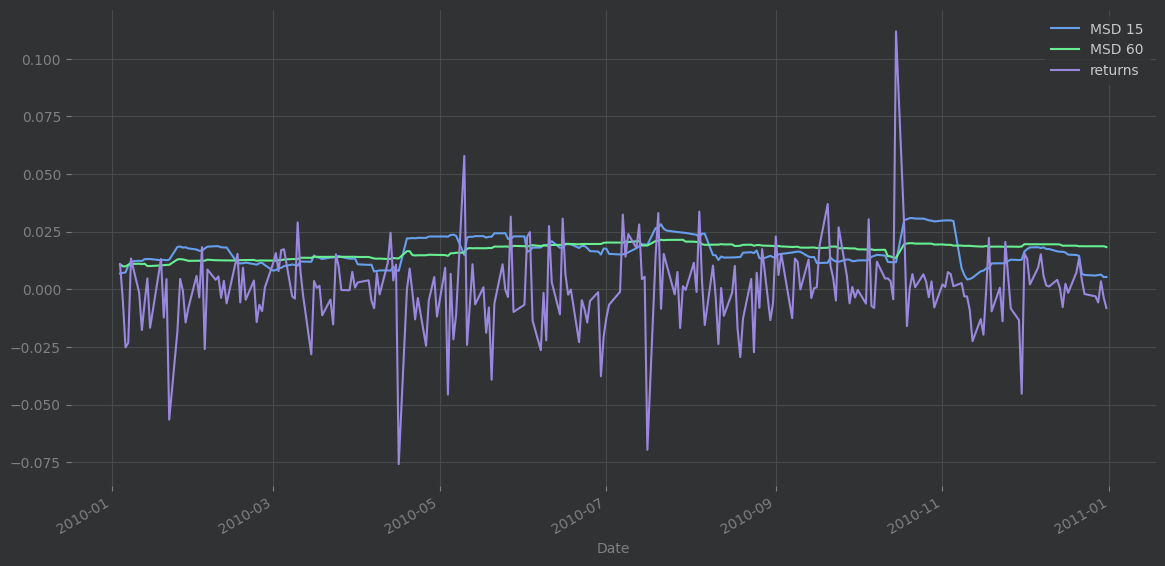

In [23]:
df[["MSD 15", "MSD 60", "returns"]].loc["2010"].plot(figsize = (14,7))

# Librería Technical Analysis (ta)
https://technical-analysis-library-in-python.readthedocs.io/en/latest/ta.html

Puedes consultar este enlace (documentación oficial de ta) si quieres usar otro indicador. (Esta no es la librería ta-lib, no te equivoques)

In [24]:
# Importar la librería ta
import ta
RSI = ta.momentum.RSIIndicator(df["close"], window = 14, fillna = False)
RSI

In [25]:
df["rsi"] = RSI.rsi()

<Axes: xlabel='Date'>

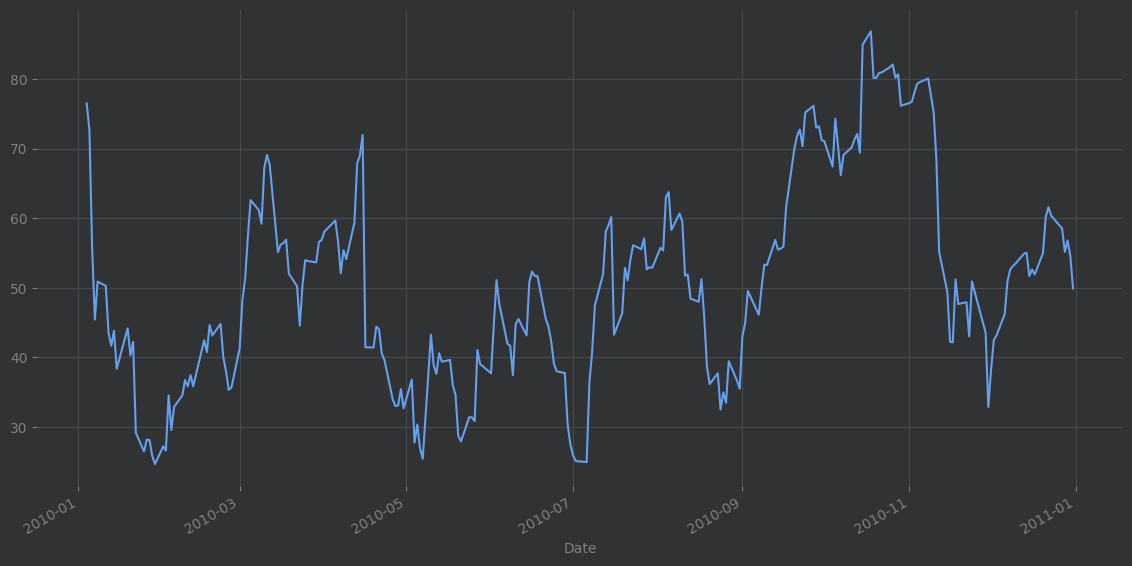

In [26]:
df["rsi"].loc["2010"].plot(figsize = (14,7))

# CREACIÓN DE LA FUNCIÓN

In [27]:
def feature_engineering(df):
    """ Crear nuevas variables"""
    # Copiamos el dataframe para evitar interferencias en los datos
    df_copy = df.copy()
    # Creamos el retorno
    df_copy["returns"] = df_copy["close"].pct_change(1)
    # Creamos las SMAs
    df_copy["SMA 15"] = df_copy[["close"]].rolling(15).mean().shift(1)
    df_copy["SMA 60"] = df_copy[["close"]].rolling(60).mean().shift(1)
    # Crear la volatilidad
    df_copy["MSD 10"] = df_copy[["returns"]].rolling(10).std().shift(1)
    df_copy["MSD 30"] = df_copy[["returns"]].rolling(30).std().shift(1)
    # Crear el RSI
    RSI = ta.momentum.RSIIndicator(df_copy["close"], window = 14, fillna = False)
    df_copy["rsi"] = RSI.rsi()

    return df_copy

In [28]:
df = yf.download("GOOG")
df = df[["Close"]]
df.columns = ["close"]

[*********************100%***********************]  1 of 1 completed


In [29]:
df

,close
Date,
2004-08-19,2.490186
2004-08-20,2.687981
2004-08-23,2.715032
2004-08-24,2.602609
2004-08-25,2.630652
...,...
2025-02-10,188.199997
2025-02-11,187.070007
2025-02-12,185.429993


In [30]:
feature_engineering(df)

,close,returns,SMA 15,SMA 60,MSD 10,MSD 30,rsi
Date,,,,,,,
2004-08-19,2.490186,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-20,2.687981,0.079430,NaN,NaN,NaN,NaN,NaN
2004-08-23,2.715032,0.010064,NaN,NaN,NaN,NaN,NaN
2004-08-24,2.602609,-0.041408,NaN,NaN,NaN,NaN,NaN
2004-08-25,2.630652,0.010775,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2025-02-10,188.199997,0.005664,198.602668,188.650950,0.031713,0.020946,42.389258
2025-02-11,187.070007,-0.006004,197.979335,188.758220,0.029634,0.020914,41.364245
2025-02-12,185.429993,-0.008767,197.142001,188.824182,0.028831,0.020930,39.857827
